# Setup

In [99]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
import sys
sys.path.append("../")

from utils.seed_all import seed_all

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

In [101]:
def plot_img_loss(img_loss, min=None, max=None, targets=[], name='Mean Image Loss Map'):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i, color='red', linewidth=1.5, alpha=0.2)  # top edge
            # plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title(name)
    plt.tight_layout()
    plt.show()
    plt.close()

# Prediction

In [102]:
path = '../runs/tcn_pred_TOWIDS_20250912_155527/train_labels_predictions.pt'
cache = torch.load(path, weights_only=False)
y_true, y_out = cache['y_true'], cache['y_scores']
y_pred, y_scores = y_out
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

In [104]:
y_true['scores'] = y_scores.mean(axis=(1, 2))

In [74]:
y_true.head()

,label,start_idx,desc_windows,scores
0,Frame Injection,831090,"[Frame Injection, Frame Injection, Frame Injec...",6.126118e-05
1,Frame Injection,819979,"[Frame Injection, Frame Injection, Frame Injec...",2.164331e-08
2,Normal,4850,"[Normal, Normal, Normal, Normal, Normal, Norma...",3.269571e-07
3,Frame Injection,891142,"[Frame Injection, Frame Injection, Frame Injec...",9.690701e-08
4,Frame Injection,825359,"[Normal, Normal, Normal, Normal, Normal, Norma...",5.187680e-05


In [81]:
fn = y_true[(y_true['scores'] < 1.2369906698950217e-06) & (y_true['label'] != 'Normal')].index
tp = y_true[(y_true['scores'] >= 1.2369906698950217e-06) & (y_true['label'] != 'Normal')].index

In [92]:
desc_windows_fn = np.array([[j == 'Normal' for j in i] for i in y_true['desc_windows'].iloc[fn].values], dtype=int)
desc_windows_tp = np.array([[j == 'Normal' for j in i] for i in y_true['desc_windows'].iloc[tp].values], dtype=int)

In [93]:
desc_windows_fn.sum(1).std()

np.float64(16.091056572283257)

<Axes: ylabel='Frequency'>

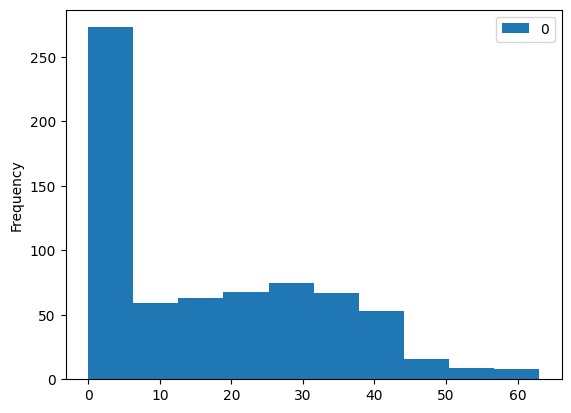

In [94]:
pd.DataFrame(desc_windows_fn.sum(1)).plot.hist()

<Axes: ylabel='Frequency'>

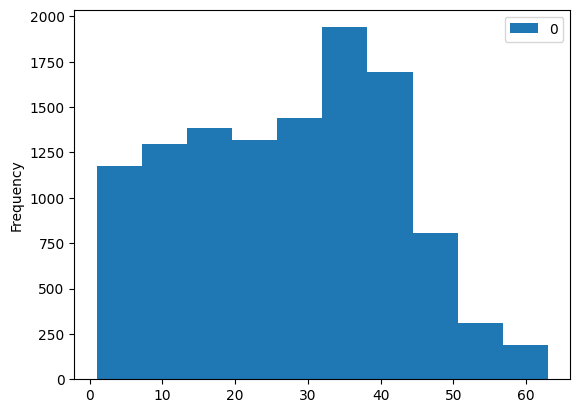

In [95]:
pd.DataFrame(desc_windows_tp.sum(1)).plot.hist()

In [97]:
from scipy.stats import ks_2samp

stat, p_value = ks_2samp(desc_windows_fn.sum(1), desc_windows_tp.sum(1))
print("KS test statistic:", stat)
print("p-value:", p_value)

KS test statistic: 0.31065052904621454
p-value: 2.1842886044517324e-56


In [98]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(desc_windows_fn.sum(1), desc_windows_tp.sum(1))
print("Mann-Whitney U test statistic:", stat)
print("p-value:", p_value)

Mann-Whitney U test statistic: 2397476.0
p-value: 5.796525338992638e-70


In [85]:
desc_windows_tp.sum(1).std()

np.float64(14.39108653089795)

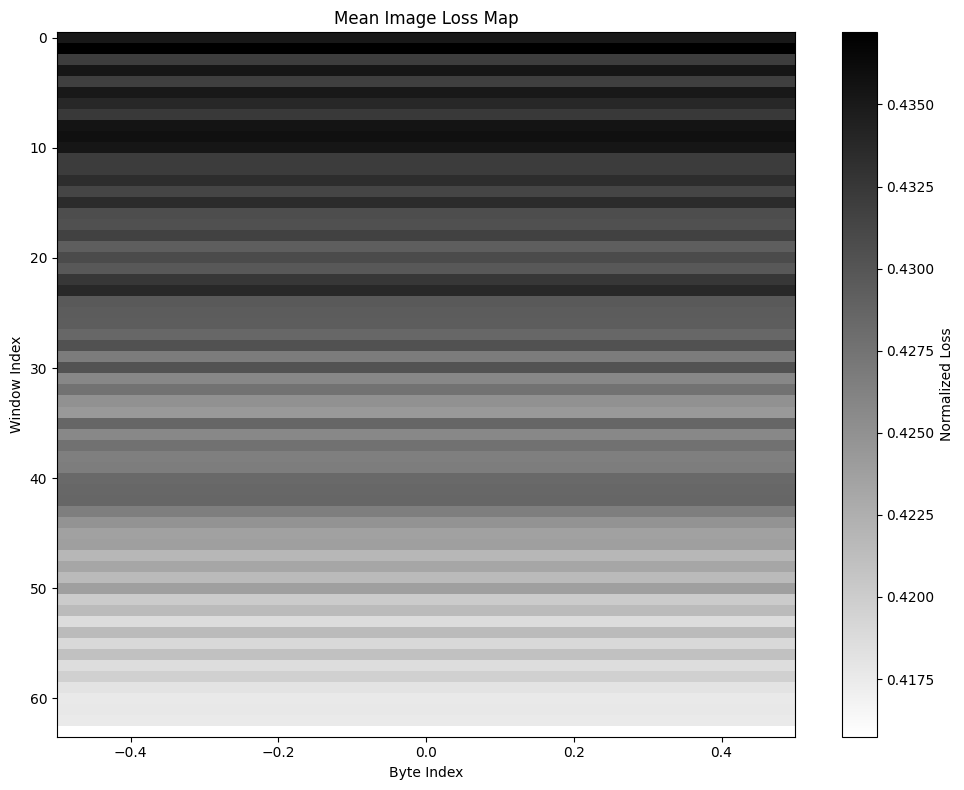

In [96]:
plot_img_loss(np.expand_dims(desc_windows_tp.mean(0), axis=1))

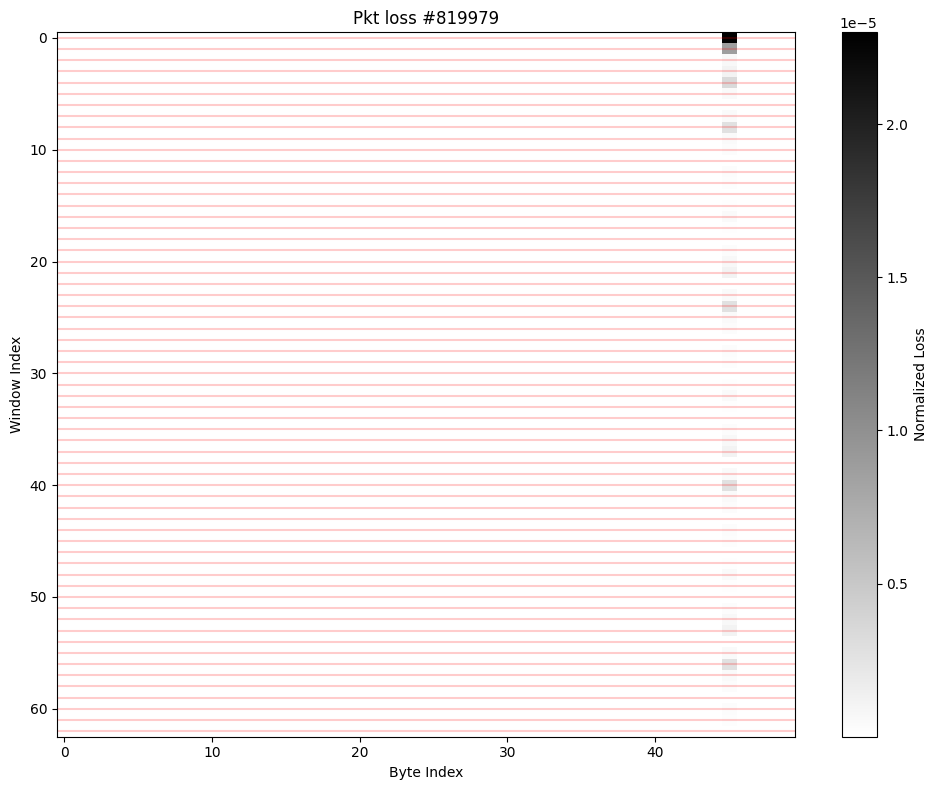

In [57]:
idx = fn[0]
plot_img_loss(y_scores[idx], targets=y_true['desc_windows'].iloc[idx][1:], name=f'Pkt loss #{y_true['start_idx'].iloc[idx]}')

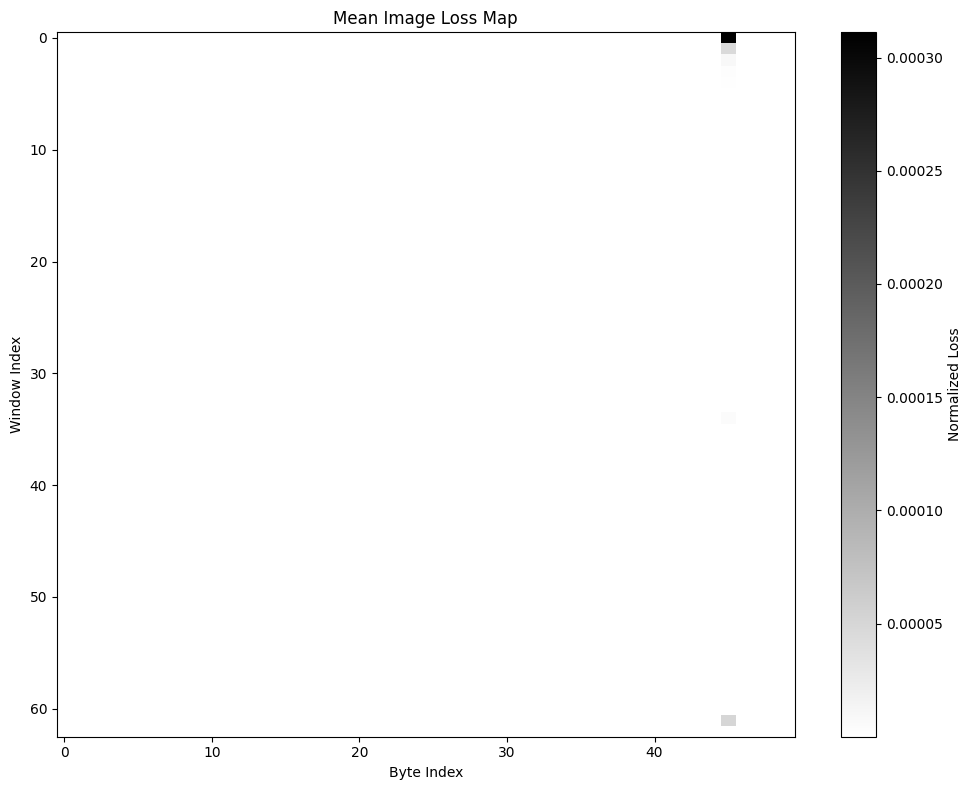

In [17]:
idx = y_true[y_true['label'] == 'Normal'].index
plot_img_loss(y_scores[fn].mean(0))

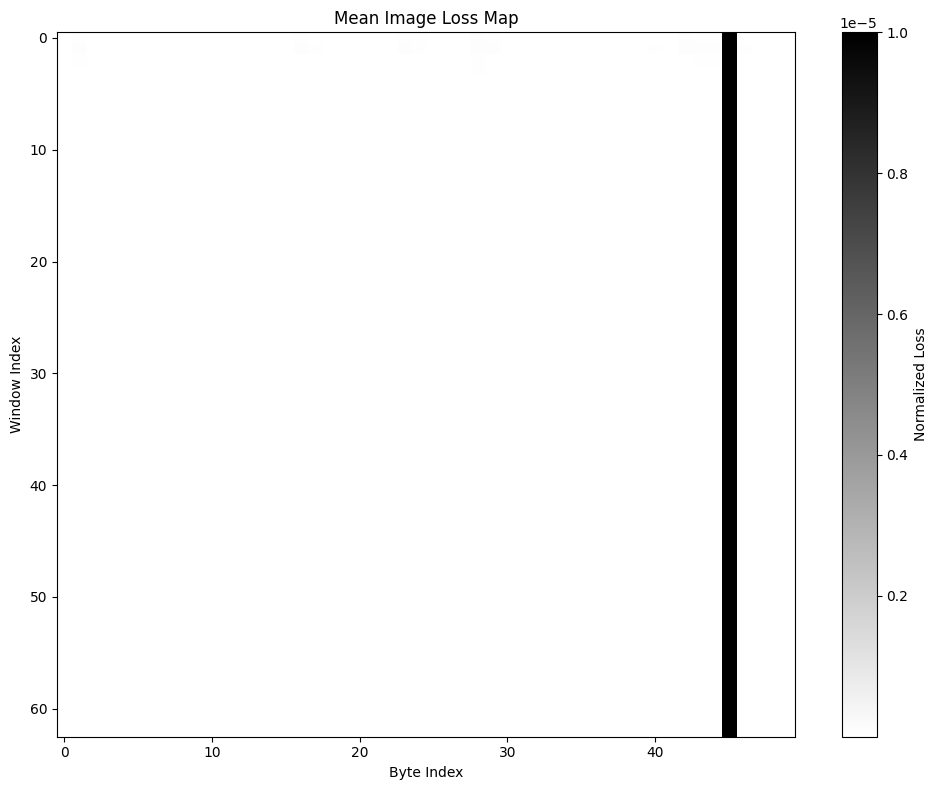

In [227]:
idx = y_true[y_true['label'] != 'Normal'].index
plot_img_loss(y_scores[idx].mean(0), max=0.00001)

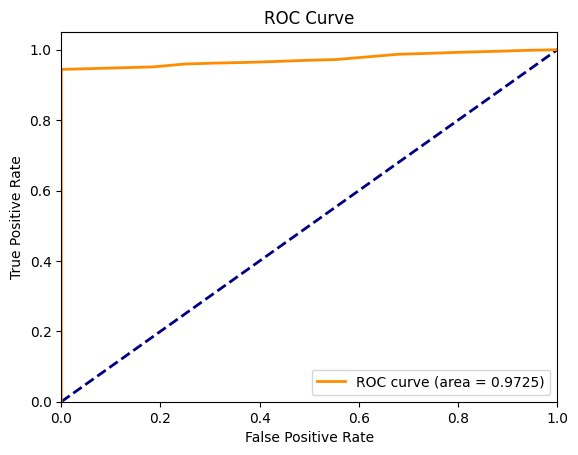

In [29]:
from sklearn.metrics import roc_auc_score, roc_curve


fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
aucroc = roc_auc_score([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()

In [111]:
fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
df_val_roc = pd.DataFrame({'fpr':fpr, 'tpr':tpr, 'thresholds':thresholds})
df_val_roc['youden-index'] = df_val_roc['tpr'] - df_val_roc['fpr']
df_val_roc.sort_values('youden-index', ascending=False).drop_duplicates('fpr')

,fpr,tpr,thresholds,youden-index
1622,0.000000,0.944005,1.091649e-06,0.944005
1623,0.063977,0.946535,9.665507e-07,0.882558
1624,0.123879,0.948821,8.304461e-07,0.824941
1625,0.184841,0.951188,3.269571e-07,0.766347
1626,0.249796,0.959432,9.690701e-08,0.709636
1627,0.310432,0.962044,5.787489e-08,0.651612
1628,0.371475,0.963840,4.087368e-08,0.592365
1629,0.430888,0.966533,3.182974e-08,0.535645
1630,0.492747,0.969798,3.148673e-08,0.477052
1631,0.553627,0.972084,2.763905e-08,0.418457


In [115]:
y_true_benign = y_true[y_true["label"] == 'Normal']

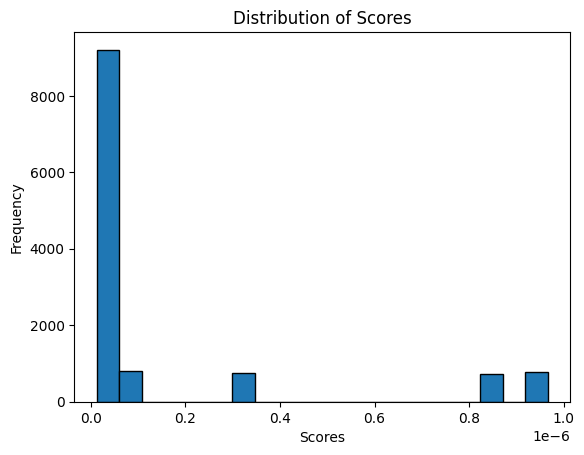

In [117]:
plt.hist(y_true_benign["scores"], bins=20, edgecolor="black")

plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.title("Distribution of Scores")
plt.show()

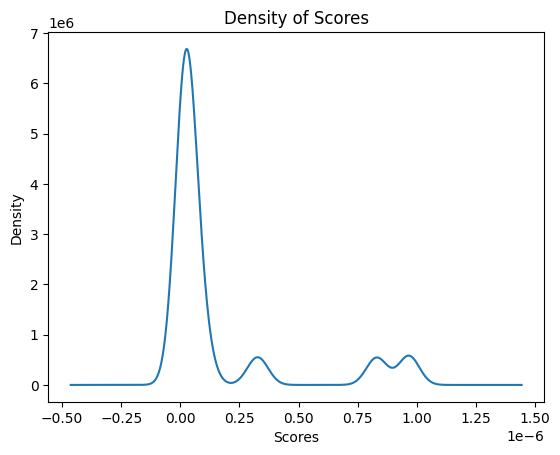

In [118]:
y_true_benign["scores"].plot(kind="kde", title="Density of Scores")
plt.xlabel("Scores")
plt.show()

In [132]:
threshold = y_true_benign["scores"].quantile(0.9999)

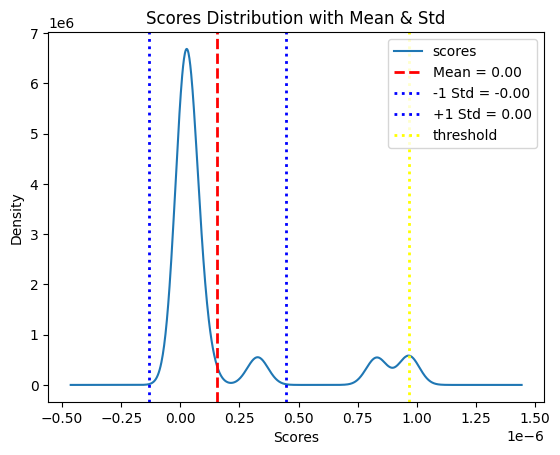

In [133]:
# Calculate mean and std
mean = y_true_benign["scores"].mean()
std = y_true_benign["scores"].std()

# Plot histogram + KDE
# y_true_benign["scores"].plot(kind="hist", bins=20, density=True, alpha=0.6, edgecolor="black")
y_true_benign["scores"].plot(kind="kde")

# Add mean line
plt.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean:.2f}")

# Add ±1 std lines
plt.axvline(mean - std, color="blue", linestyle=":", linewidth=2, label=f"-1 Std = {mean-std:.2f}")
plt.axvline(mean + std, color="blue", linestyle=":", linewidth=2, label=f"+1 Std = {mean+std:.2f}")
plt.axvline(threshold, color="yellow", linestyle=":", linewidth=2, label=f"threshold")

plt.xlabel("Scores")
plt.title("Scores Distribution with Mean & Std")
plt.legend()
plt.show()

In [137]:
mean, std, threshold

(np.float32(1.5701924e-07), np.float32(2.901218e-07), np.float32(9.665507e-07))

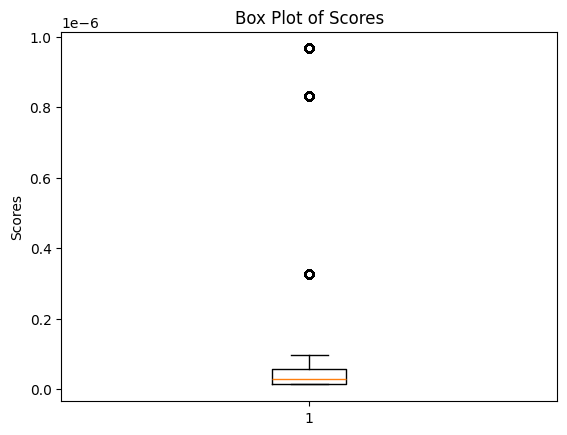

In [124]:
plt.boxplot(y_true_benign["scores"])
plt.title("Box Plot of Scores")
plt.ylabel("Scores")
plt.show()

In [136]:
from scipy.stats import genpareto

losses = y_true_benign["scores"].values

# Step 1: Choose high threshold (e.g., 95th percentile)
threshold = np.percentile(losses, 95)
excesses = losses[losses > threshold] - threshold

# Step 2: Fit Generalized Pareto Distribution (GPD) to excesses
params = genpareto.fit(excesses)  # (shape, loc, scale)

# Step 3: Compute anomaly threshold at extreme quantile (e.g., 99.9%)
quantile = genpareto.ppf(0.999, *params) + threshold

print(f"EVT-based anomaly threshold: {quantile:.6f}")

ValueError: zero-size array to reduction operation minimum which has no identity